# Visualize the M3 artifact — `lilylet/m3/notagenx-from-abc.pt`

Inspects the paired Lilylet-patch / ABC-M3-embedding dataset produced by
`tools/lilylet/preprocessLilyletM3.py`. The `m3_embedding` is now the
**mean-pooled** `[768]` vector per piece (format `lilylet-m3-abc-pooled`);
`m3_patches` records the original pre-pooling patch count.

1. Overview & per-sample shapes
2. Patch-count distributions (Lilylet vs M3)
3. **Patch text content of one sample** — verify the segmentation logic
4. Mean-pooled M3 vectors — PCA scatter colored by period / genre
5. Cross-piece cosine-similarity matrix

Run from this directory (`tests/lilylet/`).


In [1]:
from pathlib import Path
import sys, collections

REPO_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'starry').is_dir())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import torch
import numpy as np
import matplotlib.pyplot as plt

ART = Path.home() / 'data/lilylet/m3/notagenx-from-abc.pt'
art = torch.load(ART, weights_only=False)
items = art['items']
print('format :', art['format'])
print('config :', {k: v for k, v in art['config'].items() if k != 'm3'})
print('m3     :', art['config']['m3'])
print('stats  :', art['stats'])
print('items  :', len(items))


format : lilylet-m3-abc-pooled
config : {'patch_size': 64, 'patch_length': 2048, 'patch_stream': True}
m3     : {'weights': '/home/camus/.cache/huggingface/hub/models--sander-wood--clamp3/snapshots/355625cc1c6f73726bbcd0eb9276ac7152d56426/weights_clamp3_saas_h_size_768_t_model_FacebookAI_xlm-roberta-base_t_length_128_a_size_768_a_layers_12_a_length_128_s_size_768_s_layers_12_p_size_64_p_length_512.pth', 'hidden': 768, 'patch_size': 64, 'pooling': 'mean'}
stats  : {'files': 215, 'paired': 215, 'missing_abc': 0, 'unknown_total': 0}
items  : 215


## Parse metadata from filenames

Filenames follow `DATE_TIME_Period_Composer_Genre_postinst.lyl`.

In [2]:
def parse_meta(path):
    parts = Path(path).stem.split('_')
    return dict(period=parts[2] if len(parts) > 2 else '?',
                composer=parts[3] if len(parts) > 3 else '?',
                genre=parts[4] if len(parts) > 4 else '?')

meta = [parse_meta(it['path']) for it in items]
print('periods:', dict(collections.Counter(m['period'] for m in meta)))
print('genres :', dict(collections.Counter(m['genre'] for m in meta)))


periods: {'Baroque': 2, 'Classical': 93, 'Romantic': 120}
genres : {'Keyboard': 134, 'Art Song': 12, 'Orchestral': 41, 'Chamber': 28}


## 1. Per-sample shapes

In [3]:
lyl_counts = np.array([it['patches'].shape[0] for it in items])
m3_counts = np.array([it['m3_patches'] for it in items])

print('Lilylet patches  min/median/max: %d / %d / %d' % (lyl_counts.min(), int(np.median(lyl_counts)), lyl_counts.max()))
print('M3      patches  min/median/max: %d / %d / %d' % (m3_counts.min(), int(np.median(m3_counts)), m3_counts.max()))
print('m3_embedding (pooled) shape:', tuple(items[0]['m3_embedding'].shape))
print()
for it in items[:5]:
    print('%-58s lyl=%-9s m3_patches=%-5d emb=%s' % (
        it['path'][:56], tuple(it['patches'].shape), it['m3_patches'], tuple(it['m3_embedding'].shape)))


Lilylet patches  min/median/max: 27 / 201 / 2048
M3      patches  min/median/max: 98 / 288 / 5244
m3_embedding (pooled) shape: (768,)

20250408_163741_Baroque_Bach, Johann Sebastian_Keyboard_   lyl=(153, 64) m3_patches=267   emb=(768,)
20250408_164339_Classical_Haydn, Joseph_Keyboard_postins   lyl=(223, 64) m3_patches=433   emb=(768,)
20250408_171004_Classical_Mozart, Wolfgang Amadeus_Keybo   lyl=(220, 64) m3_patches=352   emb=(768,)
20250408_171712_Classical_Mozart, Wolfgang Amadeus_Keybo   lyl=(277, 64) m3_patches=532   emb=(768,)
20250408_172011_Classical_Beethoven, Ludwig van_Keyboard   lyl=(122, 64) m3_patches=195   emb=(768,)


## 2. Patch-count distributions

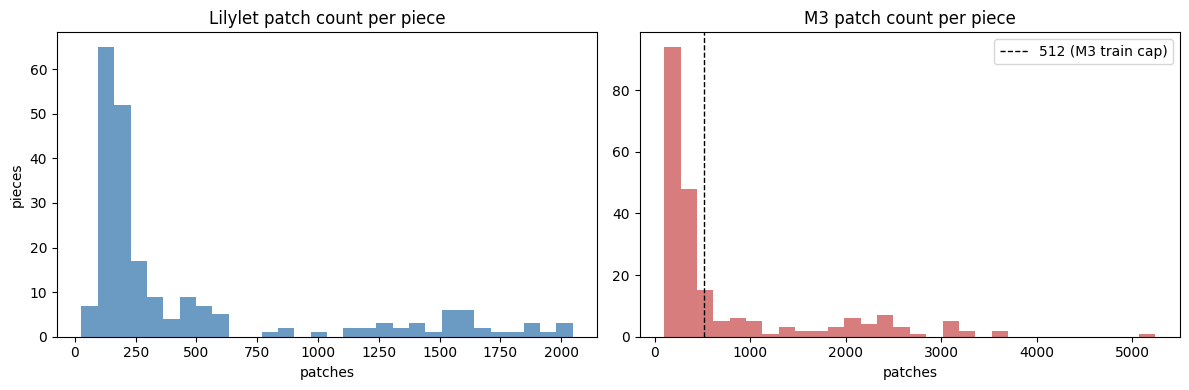

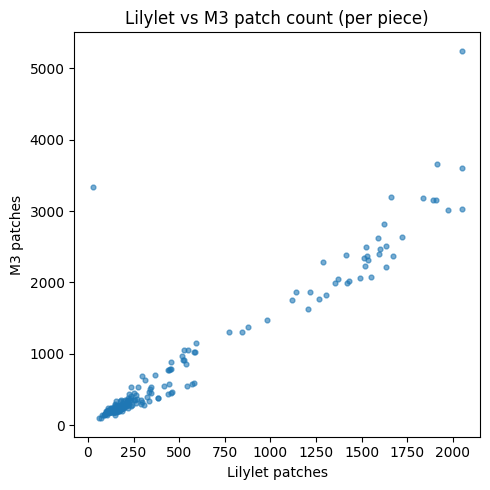

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(lyl_counts, bins=30, color='steelblue', alpha=0.8)
ax[0].set_title('Lilylet patch count per piece'); ax[0].set_xlabel('patches'); ax[0].set_ylabel('pieces')
ax[1].hist(m3_counts, bins=30, color='indianred', alpha=0.8)
ax[1].axvline(512, color='k', ls='--', lw=1, label='512 (M3 train cap)')
ax[1].set_title('M3 patch count per piece'); ax[1].set_xlabel('patches'); ax[1].legend()
plt.tight_layout(); plt.show()

plt.figure(figsize=(5, 5))
plt.scatter(lyl_counts, m3_counts, s=12, alpha=0.6)
plt.xlabel('Lilylet patches'); plt.ylabel('M3 patches')
plt.title('Lilylet vs M3 patch count (per piece)')
plt.tight_layout(); plt.show()


## 3. Patch text content of one sample — verify segmentation

The pooled embedding hides the per-patch structure, so re-run the patchilizers
on one piece's source files and **decode each patch back to text**. This checks
that:
  - Lilylet patches (`patches` in the artifact) match `M3Patchilizer(syntax='lilylet')`
    on the `.lyl` (metadata/style lines as patches, then measure → voice segments);
  - ABC patches match `M3Patchilizer(syntax='abc')` on the `.abc` (header/`%%` lines
    as patches, body split at barlines).

No model weights needed — patchilization is pure text segmentation.


In [5]:
from starry.lilylet.data.patchifier import LilyletTokenizer, patchify_text
from starry.lilylet.m3 import M3Patchilizer

SAMPLE = 0
item = items[SAMPLE]
stem = Path(item['path']).stem
print('sample:', item['path'])

tok = LilyletTokenizer(str(REPO_ROOT / art['tokenizer']['path']))
lyl_path = Path('/home/camus/work/lilylet/tests/output/notagenx-from-abc') / (stem + '.lyl')
abc_path = Path.home() / 'data/abc/notagenx-samples' / (stem + '.abc')

def decode_lyl(ids):
    return ''.join(tok.text_by_id.get(int(t), '\\x%02x' % int(t)) for t in ids if int(t) != tok.pad_id)


sample: 20250408_163741_Baroque_Bach, Johann Sebastian_Keyboard_postinst.lyl


### 3a. Lilylet patches (`syntax='lilylet'`)

Decode the artifact's stored `patches` and cross-check against a fresh
`patchify_text` call on the `.lyl` source.

  The stored Lilylet patches drop the leading `%style` prompt lines (`drop_style_comments=True`), so they encode real musical content aligned with the ABC M3 embedding — hence patches start at `<bos>` / `[staves]`.

In [6]:
patch_size = art['config']['patch_size']
N_SHOW = 12

stored = item['patches']
print('stored lilylet patches:', tuple(stored.shape), '(showing first %d)\n' % N_SHOW)
for i, p in enumerate(stored[:N_SHOW]):
    print('  [%2d] %s' % (i, repr(decode_lyl(p))[:88]))

# cross-check: re-patchify the .lyl source and compare patch ids
lyl_text = lyl_path.read_text(encoding='utf-8')
fresh, _ = patchify_text(lyl_text, tok, file=stem,
                         patch_size=patch_size,
                         patch_length=art['config']['patch_length'],
                         patch_stream=art['config']['patch_stream'],
                         drop_style_comments=True)  # match preprocessLilyletM3.py
print('\nre-patchified shape:', tuple(fresh.shape),
      '| identical to stored:', bool(torch.equal(fresh, stored)))


stored lilylet patches: (153, 64) (showing first 12)

  [ 0] '<bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><bos><b
  [ 1] '[staves "{-}"]\n<eos>'
  [ 2] '[instrument-1-2 "Harp"]\n<eos>'
  [ 3] '[r:0/63]\\staff "1" \\key d \\major \\time 3/4 \\clef "treble" b\'8 cs16 d cs8 b as b \
  [ 4] '\n\\staff "2" \\clef "bass" b,4 b\' d |\n<eos>'
  [ 5] '[r:1/62]\\staff "1" \\key d \\major \\time 3/4 g\'\'4 fs e \\\\<eos>'
  [ 6] '\n\\staff "2" cs8 d16 e d8 cs b as |\n<eos>'
  [ 7] '[r:2/61]\\staff "1" \\key d \\major \\time 3/4 d\'8 e16 fs e8 d cs b \\\\<eos>'
  [ 8] '\n\\staff "2" b4 g e |\n<eos>'
  [ 9] '[r:3/60]\\staff "1" \\key d \\major \\time 3/4 as\'8 b16 cs fs,8 gs as b \\\\<eos>'
  [10] '\n\\staff "2" fs,4 fs\' e |\n<eos>'
  [11] '[r:4/59]\\staff "1" \\key d \\major \\time 3/4 cs\'8 d16 e d8 cs b as \\\\<eos>'

re-patchified shape: (153, 64) | identical to stored: True


### 3b. ABC M3 patches (`syntax='abc'`)

The artifact only keeps the pooled ABC embedding, so re-segment the `.abc`
source with the ABC patchilizer and decode each patch to verify the barline /
header splitting.

In [7]:
abc_patchilizer = M3Patchilizer(syntax='abc')
abc_text = abc_path.read_text(encoding='utf-8')
# encode_abc filters leading '%' comment lines for ABC; mirror that here
filtered = ''.join(l for l in abc_text.splitlines(keepends=True)
                   if not (l.startswith('%') and not l.startswith('%%')))
abc_patches = abc_patchilizer.encode(filtered, add_special_patches=True)
print('ABC M3 patches:', len(abc_patches), '(matches m3_patches=%d: %s)\n'
      % (item['m3_patches'], len(abc_patches) == item['m3_patches']))

print('first patches (decoded):')
for i, p in enumerate(abc_patches[:8]):
    print('  [%2d] %s' % (i, repr(abc_patchilizer.patch2bar(p))[:88]))
print('  ...')
print('body patches (around the first bar lines):')
for i, p in enumerate(abc_patches[8:16], start=8):
    print('  [%2d] %s' % (i, repr(abc_patchilizer.patch2bar(p))[:88]))


ABC M3 patches: 267 (matches m3_patches=267: True)

first patches (decoded):
  [ 0] ''
  [ 1] 'X:1\n'
  [ 2] '%%score { ( 1 3 ) | ( 2 4 ) }\n'
  [ 3] 'L:1/8\n'
  [ 4] 'M:3/4\n'
  [ 5] 'K:D\n'
  [ 6] 'V:1 treble nm="Harp"\n'
  [ 7] 'V:3 treble \n'
  ...
body patches (around the first bar lines):
  [ 8] 'V:2 bass \n'
  [ 9] 'V:4 bass \n'
  [10] '[V:1]Bc/d/ cB^AB|'
  [11] '[V:2]B,,2 B,2 D2|'
  [12] '[V:3]x6|'
  [13] '[V:4]x6|\n'
  [14] '[V:1]g2 f2 e2|'
  [15] '[V:2]CD/E/ DCB,^A,|'


### 3c. Patch length usage

How full are the 64-slot patches? Most ABC bars are short; this shows the
distribution of real (non-pad) characters per patch for this piece.

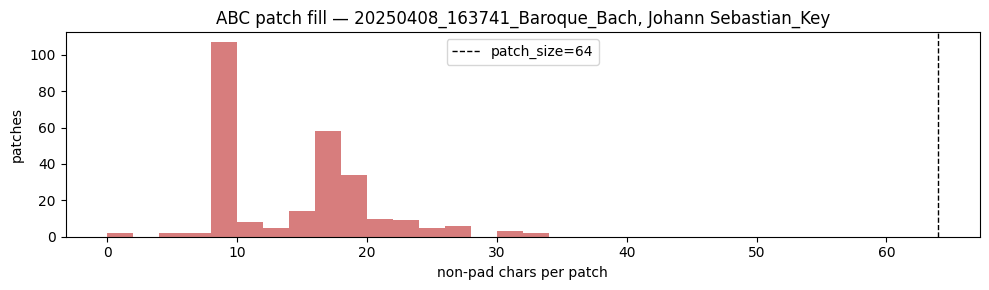

chars/patch  min/median/max: 0 / 15 / 32
patches hitting the 64 cap (truncated bars): 0


In [8]:
lengths = [sum(1 for t in p if t > abc_patchilizer.mask_token_id) for p in abc_patches]
plt.figure(figsize=(10, 3))
plt.hist(lengths, bins=range(0, 66, 2), color='indianred', alpha=0.8)
plt.axvline(64, color='k', ls='--', lw=1, label='patch_size=64')
plt.xlabel('non-pad chars per patch'); plt.ylabel('patches'); plt.legend()
plt.title('ABC patch fill — %s' % stem[:50])
plt.tight_layout(); plt.show()
print('chars/patch  min/median/max: %d / %d / %d' % (min(lengths), int(np.median(lengths)), max(lengths)))
print('patches hitting the 64 cap (truncated bars):', sum(1 for L in lengths if L >= 64))


## 4. Mean-pooled M3 vectors — PCA scatter

`m3_embedding` is already the pooled `[768]` vector, so stack directly and
project to 2-D with PCA (torch SVD). Colored by period and genre.

In [9]:
pooled = torch.stack([it['m3_embedding'].float() for it in items])
print('pooled:', tuple(pooled.shape))

X = pooled - pooled.mean(dim=0, keepdim=True)
U, S, Vh = torch.linalg.svd(X, full_matrices=False)
pcs = (X @ Vh[:2].T).numpy()
var = (S ** 2 / (S ** 2).sum())[:2].numpy()
print('explained variance PC1/PC2: %.1f%% / %.1f%%' % (var[0] * 100, var[1] * 100))


pooled: (215, 768)
explained variance PC1/PC2: 21.0% / 6.0%


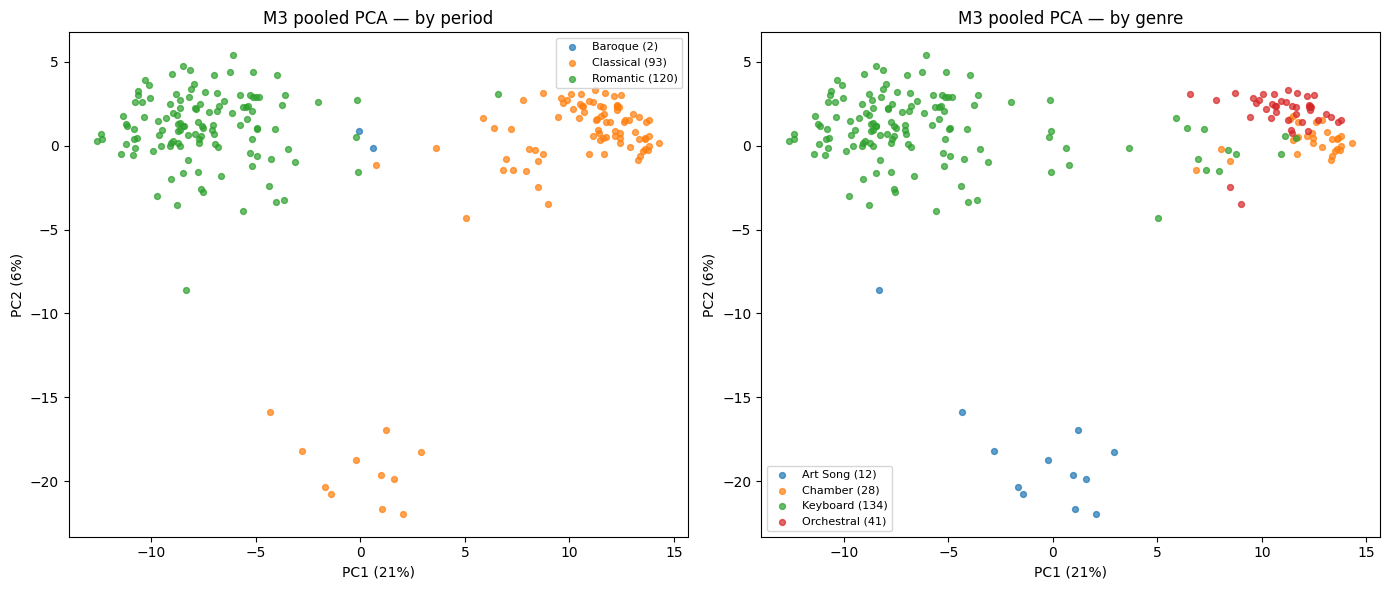

In [10]:
def scatter_by(key, ax):
    labels = [m[key] for m in meta]
    cmap = plt.get_cmap('tab10')
    for i, cat in enumerate(sorted(set(labels))):
        sel = [j for j, l in enumerate(labels) if l == cat]
        ax.scatter(pcs[sel, 0], pcs[sel, 1], s=18, alpha=0.7, color=cmap(i % 10), label='%s (%d)' % (cat, len(sel)))
    ax.set_title('M3 pooled PCA — by %s' % key)
    ax.set_xlabel('PC1 (%.0f%%)' % (var[0] * 100)); ax.set_ylabel('PC2 (%.0f%%)' % (var[1] * 100))
    ax.legend(fontsize=8)

fig, ax = plt.subplots(1, 2, figsize=(14, 6))
scatter_by('period', ax[0]); scatter_by('genre', ax[1])
plt.tight_layout(); plt.show()


## 5. Cross-piece cosine-similarity matrix

Cosine similarity between the pooled vectors, sorted by period/genre so block
structure (if any) is visible.

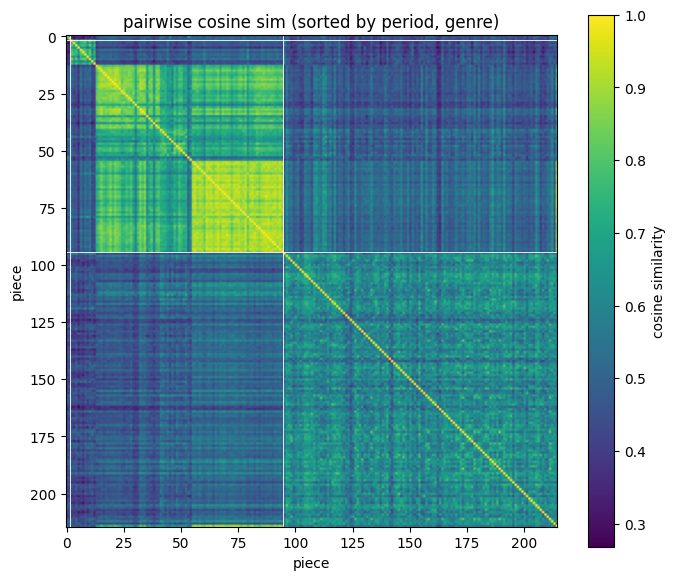

mean off-diagonal similarity: 0.572


In [11]:
order = sorted(range(len(items)), key=lambda j: (meta[j]['period'], meta[j]['genre']))
P = torch.nn.functional.normalize(pooled[order], dim=1)
sim = (P @ P.T).numpy()

plt.figure(figsize=(7, 6))
plt.imshow(sim, cmap='viridis')
plt.colorbar(label='cosine similarity')
plt.title('pairwise cosine sim (sorted by period, genre)')
plt.xlabel('piece'); plt.ylabel('piece')

sorted_periods = [meta[j]['period'] for j in order]
for b in [k for k in range(1, len(sorted_periods)) if sorted_periods[k] != sorted_periods[k-1]]:
    plt.axhline(b - 0.5, color='w', lw=0.6); plt.axvline(b - 0.5, color='w', lw=0.6)
plt.tight_layout(); plt.show()

print('mean off-diagonal similarity: %.3f' % sim[~np.eye(len(sim), dtype=bool)].mean())
